# Laboratorio 5 - Lab guiado

# **Julián Maroto, Luciana Carabaguiaz, Diego Diaz, Santiago Volio**

## Parte 1 – Aplicación Formal de PCA

### 1.1. Cargar y escalar

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = load_wine()
X = data.data
feature_names = data.feature_names

X_scaled = StandardScaler().fit_transform(X)

Preguntas que deben responder:
* Entienda y explique el contexto del dataset a trabajar:
https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009


El dataset Red Wine Quality contiene información sobre vinos tintos portugueses del tipo Vinho Verde y busca analizar cómo sus características físico-químicas influyen en la calidad percibida por catadores humanos. Incluye únicamente mediciones de laboratorio, como acidez, pH, densidad, azúcar residual, sulfatos y contenido de alcohol, junto con una variable de salida llamada quality, que es una puntuación sensorial entre 0 y 10 otorgada por expertos. No contiene información comercial ni de producción, como marca, tipo de uva o precio, debido a restricciones de privacidad.

Este conjunto de datos se utiliza en aprendizaje automático para predecir la calidad del vino a partir de sus propiedades químicas. Puede abordarse como un problema de regresión, al predecir la puntuación exacta, o de clasificación, al distinguir entre vinos de buena o baja calidad. Las clases no están balanceadas, ya que predominan los vinos de calidad media frente a los excelentes o deficientes. El objetivo general es identificar qué características químicas se asocian con una mayor calidad percibida.


### 1.2. Aplicar PCA completo

In [ ]:
pca = PCA()
Z = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
explained

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

Preguntas que deben responder:

* ¿Qué porcentaje de varianza explica PC1?

El PC1 explica: 0.36198848 , es decir el 36% de toda la informacion

* ¿Cuántos componentes necesitan para explicar al menos 80%?

Se necesitan 5 componentes para superar el 80%.

* ¿Qué implica que PC1 tenga ese valor?

Que PC1 explique aproximadamente el 36% de la varianza indica que existe una estructura dominante en los datos y que varias variables están correlacionadas entre sí, ya que una sola combinación lineal logra capturar más de un tercio de toda la información del dataset; esto sugiere que hay redundancia y que es posible realizar una reducción de dimensionalidad significativa.


## Parte 2 – Scree Plot

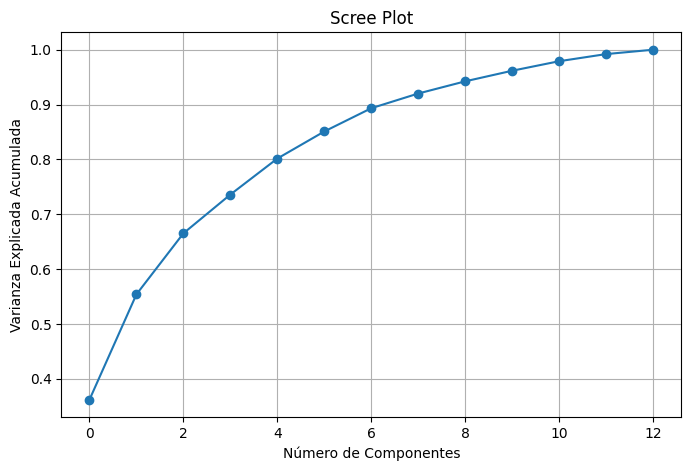

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained), marker='o')
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Scree Plot")
plt.grid()
plt.show()

Pregunta conceptual:

* ¿Dónde ocurre el “codo”?
* ¿Qué significa matemáticamente?

El “codo” ocurre entre los componentes 4 y 5, que practicamnete seria el punto donde la gráfica deja de subir de forma pronunciada y empieza a volverse más plana. Esto significa que, matemáticamente, los primeros componentes principales están explicando la mayor parte de la varianza de los datos, mientras que los siguientes aportan cada vez menos información. O de manera mas facil de decir, antes del codo cada componente añadia una cantidad importante de varianza explicada, pero después de ese punto la ganancia es mucho menor, lo que indica que esos componentes adicionales ya no son tan relevantes. Por eso, el “codo” se utiliza como referencia para elegir el número óptimo de componentes principales.

## Parte 3 – Interpretación de Eigenvectores (Loadings)

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_names))],
    index=feature_names
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664,0.213539,-0.056396,0.396139,-0.508619,0.211605,-0.225917,-0.266286,0.014970
malic_acid,-0.245188,0.224931,0.089013,0.536890,0.035214,0.536814,0.420524,0.065827,0.075283,-0.309080,0.076486,0.121696,0.025964
ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025,0.154475,-0.149171,-0.170260,0.307694,-0.027125,-0.498691,-0.049622,-0.141218
alcalinity_of_ash,-0.239320,-0.010591,0.612080,0.060859,0.066103,-0.100825,-0.286969,0.427970,-0.200449,0.052799,0.479314,-0.055743,0.091683
magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049,0.038144,0.322883,-0.156361,-0.271403,0.067870,0.071289,0.062220,0.056774


Preguntas a responder:

* Identificar las 3 variables con mayor peso absoluto para PC1 y PC2
Para PC1:
(considerando valor absoluto de los loadings visibles)

malic_acid ≈ 0.245

alcalinity_of_ash ≈ 0.239

alcohol ≈ 0.144 (muy similar a magnesium ≈ 0.142)

PC1 está dominado principalmente por variables relacionadas con acidez y composición química.

Para PC2:

alcohol ≈ 0.484

ash ≈ 0.316

magnesium ≈ 0.300
(muy cercano alcalinity_of_ash ≈ 0.316 si se incluye)

PC2 está fuertemente influido por contenido alcohólico y minerales.

* Interpretar la dirección del vector para PC1 y PC2:

En PCA, el signo indica la dirección de influencia:

Signo positivo: la variable aumenta cuando aumenta el componente

Signo negativo: la variable disminuye cuando aumenta el componente

PC1:
malic_acid y alcalinity_of_ash tienen signo negativo, mientras alcohol y magnesium son positivos. Esto sugiere un eje que contrasta vinos con mayor acidez frente a vinos con mayor contenido alcohólico/mineral.

PC2:
alcohol, ash y magnesium son positivos, por lo que PC2 representa principalmente una dimensión asociada a mayor concentración de alcohol y minerales.


* Explicar si PC1 representa una combinación de qué tipo de variables (alcohol, acidez, etc.).

PC1: Contraste entre acidez (especialmente ácido málico y alcalinidad) y componentes estructurales como alcohol y minerales.

PC2: Dimensión dominada por alcohol y minerales (cenizas y magnesio), relacionada con la “riqueza” química del vino.



* ¿Por qué hay 13 componentes?


El número máximo de componentes principales es igual al número de variables originales.

Este dataset contiene 13 variables físico-químicas, por lo tanto:

Número de componentes = número de variables = 13

Cada componente es una combinación lineal distinta de esas variables y juntos pueden reconstruir toda la información original del conjunto de datos.

## Parte 4 – Biplot Analítico

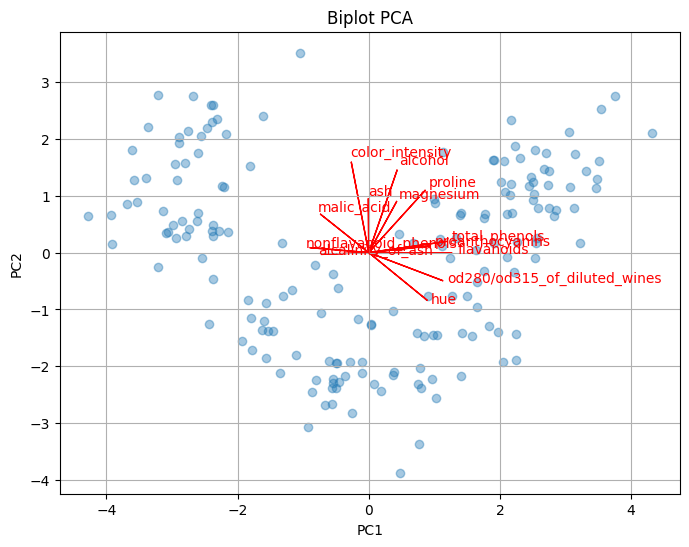

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], alpha=0.4)

for i, var in enumerate(feature_names):
    plt.arrow(0, 0,
              loadings.iloc[i,0]*3,
              loadings.iloc[i,1]*3,
              color='red')
    plt.text(loadings.iloc[i,0]*3.2,
             loadings.iloc[i,1]*3.2,
             var,
             color='red')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA")
plt.grid()
plt.show()

* ¿Qué variables forman ángulos pequeños?


Forman ángulos pequeños las variables cuyos vectores apuntan en direcciones muy similares, lo que indica alta correlación positiva entre ellas. En el gráfico se observa que alcohol, color_intensity y proline están muy alineadas. También total_phenols, flavanoids y od280/od315_of_diluted_wines presentan direcciones cercanas, indicando que tienden a aumentar juntas.


* ¿Qué variables están en direcciones opuestas?



Las variables con vectores en sentidos contrarios (≈ 180°) están negativamente correlacionadas. En el biplot, variables como malic_acid o alcalinity_of_ash apuntan hacia la izquierda, mientras alcohol, proline o color_intensity lo hacen hacia la derecha, lo que sugiere que cuando unas aumentan, las otras tienden a disminuir.



* ¿Qué significa un ángulo cercano a 90°?


Un ángulo cercano a 90° entre dos vectores indica que las variables están aproximadamente no correlacionadas (independientes linealmente). Es decir, cambios en una variable no aportan información relevante sobre la otra.


* ¿Cómo se interpreta el signo de los loadings?


El signo indica la dirección de la relación con el componente principal. Un loading positivo significa que la variable aumenta en la misma dirección del componente, mientras que uno negativo indica que aumenta en la dirección opuesta. En el biplot, esto se refleja en si el vector apunta hacia el lado positivo o negativo de los ejes PC1 y PC2.



## Parte 5 – Calcular ángulos explícitamente

In [ ]:
def angle(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2))
    return np.degrees(np.arccos(cos_theta))

angle(loadings["PC1"], loadings["PC2"])

np.float64(90.0)

In [ ]:
angle(loadings.loc["alcohol"], loadings.loc["malic_acid"])

np.float64(90.0)

Preguntas:
* ¿Coincide el ángulo con la correlación?

Sí coincide, pero no del todo.

En PCA, el ángulo entre dos vectores funciona como una “forma visual” de ver la correlación entre variables. Si el ángulo es cercano a 90°, significa que casi no están relacionadas. Si es pequeño, están positivamente relacionadas (suben o bajan juntas). Si es cercano a 180°, están negativamente relacionadas (cuando una sube, la otra baja).

## Parte 6 – Comparación con Matriz de Correlación

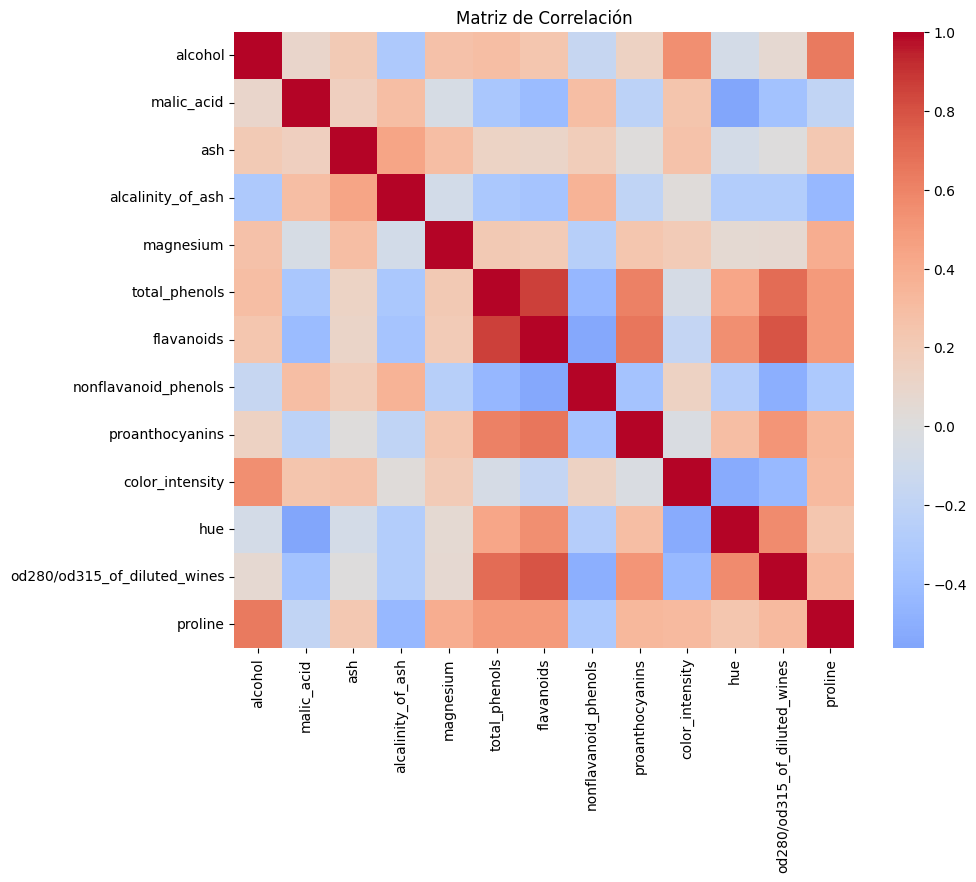

In [ ]:
df = pd.DataFrame(X_scaled, columns=feature_names)
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()

Para 3 pares de variables:

* Revisar correlación
* Revisar ángulo en biplot
* Explicar coherencia matemática

Par 1: total_phenols — flavanoids

Correlación: Muy alta y positiva (zona rojo intenso).

Ángulo en biplot: Muy pequeño; los vectores apuntan casi en la misma dirección.

Coherencia matemática: Tiene sentido porque una alta correlación positiva implica que ambas variables crecen juntas. En PCA, eso se traduce en vectores casi paralelos (ángulo cercano a 0°).

Par 2: alcohol — proline

Correlación: Positiva moderada-alta (rojo/anaranjado).

Ángulo en biplot: Pequeño, aunque no tan alineado como el caso anterior.

Coherencia matemática: Al aumentar el alcohol, también tiende a aumentar la prolina, por lo que sus direcciones en el espacio de componentes son similares. La correlación no es perfecta, por eso el ángulo no es exactamente cero.

Par 3: malic_acid — flavanoids

Correlación: Negativa (tonos azules).

Ángulo en biplot: Cercano a 180°, es decir, vectores en direcciones opuestas.

Coherencia matemática: Una correlación negativa significa que cuando una variable aumenta, la otra disminuye. En PCA esto se representa con vectores apuntando en sentidos contrarios.

En general, hay coherencia entre la matriz de correlación y el biplot porque el ángulo entre vectores en PCA está relacionado con la correlación: ángulos pequeños indican correlación positiva, cercanos a 180° indican correlación negativa y cercanos a 90° indican poca o nula relación.

## Parte 7 – Reducción Real

In [ ]:
pca2 = PCA(n_components=2)
Z2 = pca2.fit_transform(X_scaled)

Responder:


**¿Cuánta información se pierde?**


Según el scree plot, las dos primeras componentes explican aproximadamente entre 55 % y 65 % de la varianza total. Esto significa que se pierde alrededor de un 35 %–45 % de la información original al reducir a 2 dimensiones. No es una pérdida extrema, pero tampoco es despreciable.

**¿Qué estructura se conserva?**


Se conserva la estructura global de los datos: los patrones principales, agrupamientos y direcciones de mayor variabilidad. En otras palabras, se mantiene la “forma general” del conjunto de datos, permitiendo visualizar relaciones importantes entre observaciones y variables.

**¿Qué variables quedan mal representadas?**


Quedan peor representadas aquellas variables que no contribuyen mucho a PC1 y PC2, es decir, las que tienen loadings pequeños en estas componentes o cuya información está en componentes posteriores. En este dataset suelen ser variables con menor varianza o con relaciones más complejas que no se alinean con las direcciones principales, por lo que su influencia se diluye en la proyección a 2D.

# Laboratorio 5 - Lab reto
* En este lab ustedes deben crear el codigo
* Dataset: Breast Cancer (Wisconsin): https://www.kaggle.com/datasets/reihanenamdari/breast-cancer
* Herramientas permitidas: sklearn, pandas, numpy, matplotlib, seaborn


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Aplicar PCA sin limitar el número de componentes.

Obtener:

* Eigenvalues (varianza explicada)
* Eigenvectors (componentes)
* Varianza explicada acumulada
* Construir el Scree Plot.
* Construir una tabla de loadings (componentes).
* Identificar las 5 variables con mayor peso absoluto en PC1
* Construir un biplot usando PC1 y PC2.
* Escoja 2 variables que eliminaría porque no aportan mucha información (Alta correlación o angulos cercanos)


,PC,Eigenvalue (Var),Explained Var Ratio,Cumulative Explained Var
0,PC1,13.304991,0.442720,0.442720
1,PC2,5.701375,0.189712,0.632432
2,PC3,2.822910,0.093932,0.726364
3,PC4,1.984128,0.066021,0.792385
4,PC5,1.651633,0.054958,0.847343
5,PC6,1.209482,0.040245,0.887588
6,PC7,0.676409,0.022507,0.910095
7,PC8,0.477456,0.015887,0.925983
8,PC9,0.417629,0.013896,0.939879
9,PC10,0.351311,0.011690,0.951569


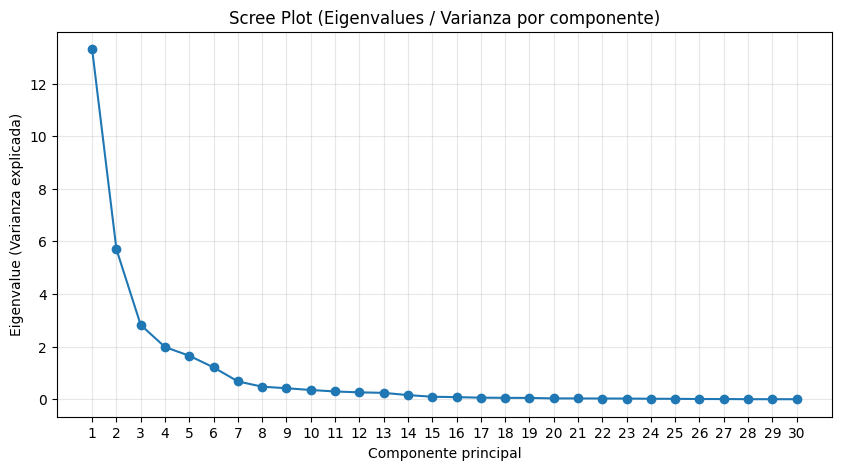

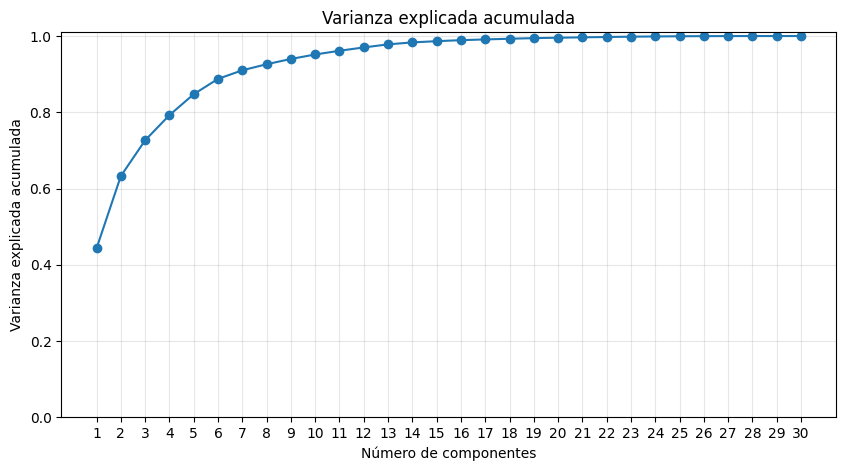

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
mean radius,0.798469,-0.558394,-0.014334,-0.058328,-0.048561,0.020610,-0.102055,-0.005149,-0.144183,0.056596,...,0.011882,-0.012091,0.015389,0.024555,0.002394,0.011719,-0.010935,-0.008427,-5.791552e-03,0.008109
mean texture,0.378346,-0.142564,0.108454,0.849451,0.063575,-0.035389,0.009375,0.090294,0.072831,0.142805,...,-0.077693,-0.015717,0.000087,-0.013286,-0.010554,0.002223,-0.001443,0.000003,2.885070e-04,0.000003
mean perimeter,0.829965,-0.513800,-0.015649,-0.059137,-0.048032,0.019035,-0.094151,-0.012913,-0.144590,0.051202,...,0.012090,-0.012461,0.006284,0.015688,-0.003364,0.011337,-0.009596,-0.003365,-1.051236e-02,-0.007965
mean area,0.806101,-0.551755,0.048220,-0.075266,-0.013277,-0.002076,-0.042482,0.023959,-0.126396,0.044428,...,0.003196,-0.016176,-0.001214,-0.009394,0.026157,-0.032830,0.038795,0.010874,1.157965e-02,-0.000380
mean smoothness,0.520110,0.444392,-0.175226,-0.224505,0.469197,-0.314945,-0.115692,-0.199676,0.004152,-0.041071,...,0.020705,-0.010581,0.003227,-0.009239,-0.003606,0.003349,0.005794,-0.000059,9.406984e-05,-0.000056
mean compactness,0.872817,0.362680,-0.124485,-0.044786,-0.015041,-0.015541,0.025429,-0.104612,-0.108466,0.007667,...,-0.033377,0.016261,-0.008176,0.014005,-0.049393,-0.023787,0.008127,0.000218,1.123382e-03,0.000516
mean concavity,0.942542,0.143660,0.004593,-0.026936,-0.111006,-0.010276,-0.088429,-0.050322,0.026232,-0.080373,...,-0.000965,0.030707,-0.050729,-0.006017,0.012077,0.049679,0.030331,-0.001817,2.742885e-04,0.000290
mean concave points,0.951490,-0.083016,-0.042951,-0.092032,0.056368,-0.057243,-0.123763,-0.105252,-0.072360,0.004774,...,0.001633,0.051703,0.008028,-0.011301,0.023219,-0.035086,-0.037805,0.000354,1.152214e-04,-0.000012
mean symmetry,0.503978,0.454506,-0.067609,-0.094552,0.393183,0.392020,-0.077220,-0.159984,0.165464,0.339074,...,0.015065,0.003052,0.007995,-0.002601,0.003061,0.001452,-0.001261,-0.000057,2.073260e-04,-0.000015
mean fractal dimension,0.234772,0.875292,-0.037928,-0.068439,0.057092,-0.131346,0.243245,-0.122388,-0.079967,0.048071,...,0.013216,-0.047727,0.013225,0.017922,0.025806,0.008816,-0.008418,0.000252,-1.999742e-04,-0.000055



Top 5 variables por |peso| en PC1 (componentes):


,Feature,PC1 Weight (component),Abs Weight
0,mean concave points,0.260854,0.260854
1,mean concavity,0.258400,0.258400
2,worst concave points,0.250886,0.250886
3,mean compactness,0.239285,0.239285
4,worst perimeter,0.236640,0.236640


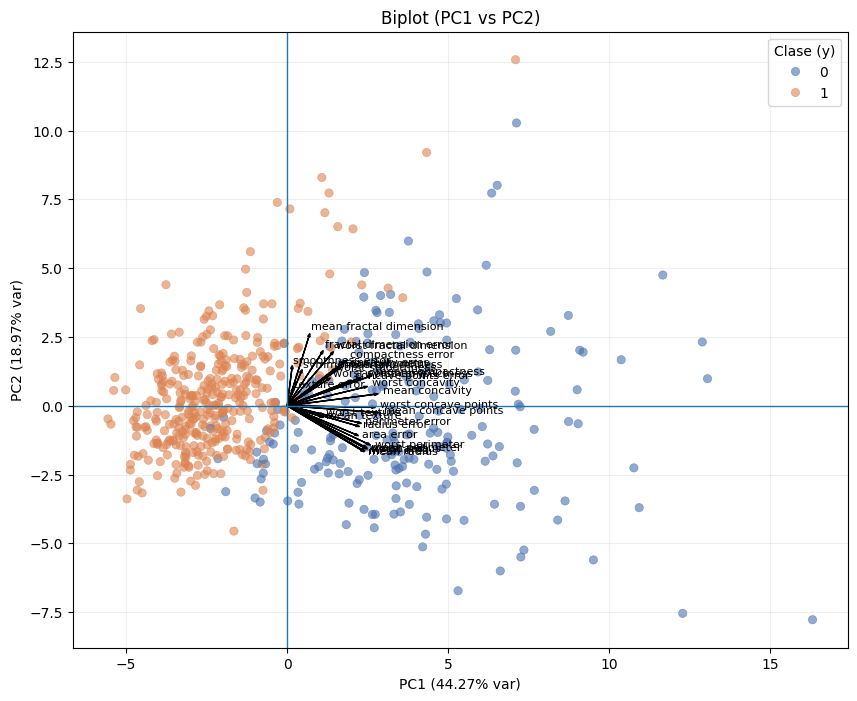


Sugerencia de 2 variables a eliminar (por alta correlación / redundancia):
- Par más correlacionado: mean radius vs mean perimeter con |corr| = 0.9979
- Contribución (norma loadings en PC1-PC2): mean radius = 0.9743, mean perimeter = 0.9761
- Sugerencia: eliminar 'mean radius' (más redundante / menor aporte en PC1-PC2) y mantener 'mean perimeter'


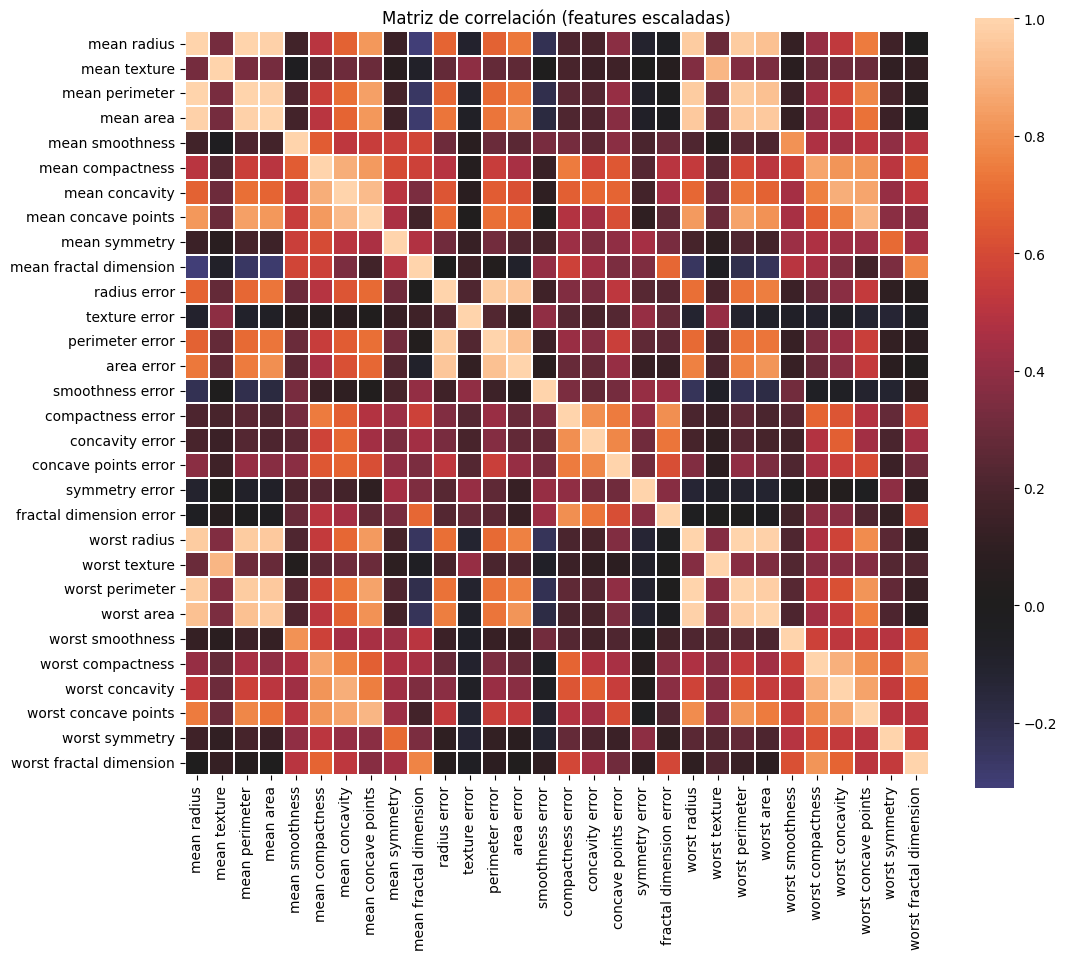

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


eigenvalues = pca.explained_variance_
eigenvectors = pca.components_


explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

# Tabla resumen de varianza explicada
ev_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Eigenvalue (Var)": eigenvalues,
    "Explained Var Ratio": explained_ratio,
    "Cumulative Explained Var": cum_explained
})
display(ev_df)

#Ploteo

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(eigenvalues)+1), eigenvalues, marker="o")
plt.title("Scree Plot (Eigenvalues / Varianza por componente)")
plt.xlabel("Componente principal")
plt.ylabel("Eigenvalue (Varianza explicada)")
plt.xticks(np.arange(1, len(eigenvalues)+1))
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cum_explained)+1), cum_explained, marker="o")
plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.xticks(np.arange(1, len(cum_explained)+1))
plt.ylim(0, 1.01)
plt.grid(True, alpha=0.3)
plt.show()


loadings = pca.components_.T * np.sqrt(eigenvalues)
loadings_df = pd.DataFrame(
    loadings,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(loadings.shape[1])]
)
display(loadings_df)


pc1_weights = pca.components_[0]
top5_idx = np.argsort(np.abs(pc1_weights))[::-1][:5]
top5_features = feature_names[top5_idx]
top5_values = pc1_weights[top5_idx]

top5_df = pd.DataFrame({
    "Feature": top5_features,
    "PC1 Weight (component)": top5_values,
    "Abs Weight": np.abs(top5_values)
}).sort_values("Abs Weight", ascending=False)

print("\nTop 5 variables por |peso| en PC1 (componentes):")
display(top5_df)

scores = X_pca[:, :2]


var_vecs = loadings[:, :2]


scale = 3.0

plt.figure(figsize=(10, 8))

sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=y, palette="deep", alpha=0.6, edgecolor=None)
plt.title("Biplot (PC1 vs PC2)")
plt.xlabel(f"PC1 ({explained_ratio[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({explained_ratio[1]*100:.2f}% var)")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

# Dibujar flechas
for i, name in enumerate(feature_names):
    x_vec, y_vec = var_vecs[i, 0]*scale, var_vecs[i, 1]*scale
    plt.arrow(0, 0, x_vec, y_vec, head_width=0.08, length_includes_head=True)
    plt.text(x_vec*1.05, y_vec*1.05, name, fontsize=8)

plt.legend(title="Clase (y)", loc="best")
plt.grid(True, alpha=0.2)
plt.show()


corr = pd.DataFrame(X_scaled, columns=feature_names).corr().abs()
np.fill_diagonal(corr.values, 0)

max_pair = np.unravel_index(np.argmax(corr.values), corr.shape)
f1, f2 = corr.index[max_pair[0]], corr.columns[max_pair[1]]
max_corr_value = corr.iloc[max_pair[0], max_pair[1]]


f1_idx = np.where(feature_names == f1)[0][0]
f2_idx = np.where(feature_names == f2)[0][0]
f1_contrib = np.linalg.norm(var_vecs[f1_idx])
f2_contrib = np.linalg.norm(var_vecs[f2_idx])

drop_feature = f1 if f1_contrib < f2_contrib else f2
keep_feature = f2 if drop_feature == f1 else f1

print("\nSugerencia de 2 variables a eliminar (por alta correlación / redundancia):")
print(f"- Par más correlacionado: {f1} vs {f2} con |corr| = {max_corr_value:.4f}")
print(f"- Contribución (norma loadings en PC1-PC2): {f1} = {f1_contrib:.4f}, {f2} = {f2_contrib:.4f}")
print(f"- Sugerencia: eliminar '{drop_feature}' (más redundante / menor aporte en PC1-PC2) y mantener '{keep_feature}'")

# Heatmap de correlacion

plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(X_scaled, columns=feature_names).corr(), center=0, square=True, linewidths=0.2)
plt.title("Matriz de correlación (features escaladas)")
plt.show()